# 01 - Clasificacion v4 | Google Cloud Compute Engine (L4)

**Este notebook es para ejecutar en el VM de Google Cloud, no en Colab.**

**Mejoras respecto a v3:**
- Dataset: NIH + CheXpert (~96k imagenes) en lugar de solo NIH (~38k)
- `BatchNormalization` en la cabeza — estabiliza el fine-tuning con 100 capas descongeladas
- `CAPAS_DESCONGELAR = 100` — adapta mas representaciones a imagenes medicas
- `FACTOR_LR = 0.3` — reduccion mas conservadora del LR
- `PACIENCIA_EARLY = 8` — mas tolerancia antes de detener el entrenamiento
- `class_weight` — compensa el desbalance 56/44 del DatasetV2
- `L2` en la capa Dense — regularizacion contra sobreajuste
- `BATCH_SIZE = 32` — aprovechar los 24 GB de VRAM de la L4
- Checkpoints separados por fase (`_f1.keras`, `_f2.keras`)
- Calibracion de umbral optimo sobre val antes de evaluar en test
- Curva ROC y tabla de comparacion contra v1, v2, v3
- Formato `.keras` en lugar de `.h5`

**Nota sobre validacion externa:** se omite el dataset Chest X-Ray porque
sus radiografias son en vista AP (anteroposterior), mientras que el modelo
fue entrenado exclusivamente con vistas PA (posteroanterior). Comparar
ambas vistas introduciria un sesgo metodologico injusto.

**Metricas a superar (modelo v2, test NIH):**

| Metrica | v1 | v2 | Objetivo v4 |
|---|---|---|---|
| Sensibilidad | 0.544 | 0.582 | > 0.582 |
| Especificidad | 0.790 | 0.756 | > 0.756 |
| Precision | 0.649 | 0.636 | > 0.636 |
| F1 | 0.592 | 0.608 | > 0.608 |

## Celda 1 — Rutas y verificacion de archivos

Define todas las rutas del VM. Si el Paso 3 mostro una estructura
diferente, ajustar `RUTA_BASE` aqui antes de continuar.

In [15]:
import tensorflow as tf
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [16]:
from pathlib import Path

RUTA_BASE        = Path("/home/user/data/DatasetV2")
RUTA_CHECKPOINTS = Path("/home/user/checkpoints")

RUTA_CHECKPOINTS.mkdir(parents=True, exist_ok=True)

for nombre in ["master_train.csv", "master_val.csv", "master_test.csv"]:
    assert (RUTA_BASE / nombre).exists(), (
        f"No se encontro: {RUTA_BASE / nombre}\n"
        f"Verificar que el Paso 2 se ejecuto correctamente."
    )

print("Archivos verificados correctamente.")
print(f"  Dataset     : {RUTA_BASE}")
print(f"  Checkpoints : {RUTA_CHECKPOINTS}")

Archivos verificados correctamente.
  Dataset     : /home/user/data/DatasetV2
  Checkpoints : /home/user/checkpoints


## Celda 2 — Verificacion de GPU

La VM L4 tiene GPU asignada al crearla. Si esta celda no detecta GPU,
verificar que el VM fue creado con acelerador L4.

In [17]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU encontrada: {gpus[0].name}")
    print("El entrenamiento usara aceleracion GPU.")
else:
    print("ERROR: No se encontro GPU.")
    print("Verificar que el VM fue creado con acelerador L4.")
    print("Detener aqui hasta resolver esto.")

GPU encontrada: /physical_device:GPU:0
El entrenamiento usara aceleracion GPU.


## Celda 3 — Importaciones y parametros

Todos los hiperparametros en un solo lugar.

- `CAPAS_DESCONGELAR = 100`: el doble que v2 — adapta mas representaciones a RX de torax
- `FACTOR_LR = 0.3`: mas conservador que v2 (0.5) — evita reducir el LR demasiado de golpe
- `PACIENCIA_EARLY = 8`: mas tolerancia que v2 (5) antes de detener
- `EPOCHS_FASE_2 = 20`: mas margen para que el fine-tuning converja
- `MONITOR_METRICA = val_auc`: guarda cuando mejora AUC, no val_loss
- Formato `.keras`: formato nativo de Keras, sin deprecation warnings

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, auc, f1_score)
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense,
                                     Dropout, BatchNormalization)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

np.random.seed(42)
tf.random.set_seed(42)

# ── Hiperparametros ───────────────────────────────────────────────
TAMANO_IMAGEN     = 224
BATCH_SIZE        = 64
EPOCHS_FASE_1     = 10
EPOCHS_FASE_2     = 20
CAPAS_DESCONGELAR = 100
LR_FASE_1         = 1e-3
LR_FASE_2         = 1e-5
FACTOR_LR         = 0.3
PACIENCIA_EARLY   = 8
SEMILLA           = 42

# ── Metrica de monitoreo ─────────────────────────────────────────
# val_auc mide capacidad discriminativa independientemente del umbral.
# En v2, monitorizar val_loss guardo checkpoints con peor AUC.
MONITOR_METRICA = "val_auc"
MONITOR_MODE    = "max"

# ── Nombres de archivos ───────────────────────────────────────────
NOMBRE_MODELO_F1 = "mejor_modelo_clasificacion_v4_f1.keras"
NOMBRE_MODELO_F2 = "mejor_modelo_clasificacion_v4_f2.keras"
NOMBRE_BACKBONE  = "backbone_densenet121_v4.keras"
NOMBRE_CURVAS    = "curvas_entrenamiento_v4.png"
NOMBRE_MATRIZ    = "matriz_confusion_v4.png"

print("Configuracion cargada.")
print(f"  Tamano imagen       : {TAMANO_IMAGEN}x{TAMANO_IMAGEN} px")
print(f"  Batch size          : {BATCH_SIZE}")
print(f"  Epochs fase 1 / 2   : {EPOCHS_FASE_1} / {EPOCHS_FASE_2}")
print(f"  Capas descongeladas : {CAPAS_DESCONGELAR}")
print(f"  LR fase 1 / 2       : {LR_FASE_1} / {LR_FASE_2}")
print(f"  Factor ReduceLR     : {FACTOR_LR}")
print(f"  Paciencia EarlyStop : {PACIENCIA_EARLY}")
print(f"  Metrica monitoreo   : {MONITOR_METRICA}")
print(f"  Checkpoint fase 1   : {NOMBRE_MODELO_F1}")
print(f"  Checkpoint fase 2   : {NOMBRE_MODELO_F2}")

Configuracion cargada.
  Tamano imagen       : 224x224 px
  Batch size          : 64
  Epochs fase 1 / 2   : 10 / 20
  Capas descongeladas : 100
  LR fase 1 / 2       : 0.001 / 1e-05
  Factor ReduceLR     : 0.3
  Paciencia EarlyStop : 8
  Metrica monitoreo   : val_auc
  Checkpoint fase 1   : mejor_modelo_clasificacion_v4_f1.keras
  Checkpoint fase 2   : mejor_modelo_clasificacion_v4_f2.keras


## Celda 4 — Cargar CSVs del DatasetV2

`path` en cada CSV es relativo a `RUTA_BASE` (ej: `train/NIH/imagen.jpg`).
El generador resuelve la ruta completa concatenando `directory + path`.

In [19]:
df_train = pd.read_csv(RUTA_BASE / "master_train.csv")
df_val   = pd.read_csv(RUTA_BASE / "master_val.csv")
df_test  = pd.read_csv(RUTA_BASE / "master_test.csv")

for df in [df_train, df_val, df_test]:
    df["label"] = df["label"].astype(int)

print("Splits cargados:")
for nombre, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    n1 = df["label"].sum()
    n0 = len(df) - n1
    print(f"  {nombre:<6}: {len(df):>7,}  (anomalas: {n1:,} | normales: {n0:,})")

Splits cargados:
  train :  67,031  (anomalas: 37,954 | normales: 29,077)
  val   :  14,541  (anomalas: 8,110 | normales: 6,431)
  test  :  14,684  (anomalas: 8,339 | normales: 6,345)


## Celda 5 — Calcular class_weight

El DatasetV2 tiene desbalance ~57/43. `compute_class_weight('balanced')`
asigna pesos inversamente proporcionales a la frecuencia de cada clase,
permitiendo usar todos los datos sin descartar imagenes.

In [20]:
pesos = compute_class_weight(
    class_weight = "balanced",
    classes      = np.array([0, 1]),
    y            = df_train["label"].values
)
class_weight_dict = {0: pesos[0], 1: pesos[1]}

print("Pesos de clase:")
print(f"  Clase 0 (normal)  : {pesos[0]:.4f}")
print(f"  Clase 1 (anomalia): {pesos[1]:.4f}")

Pesos de clase:
  Clase 0 (normal)  : 1.1526
  Clase 1 (anomalia): 0.8831


## Celda 6 — Generadores de imagenes

`class_mode='raw'` indica etiquetas numericas directas desde el CSV.
Augmentation conservador apropiado para radiografias PA:
flip horizontal valido (torax aproximadamente simetrico),
rotaciones y desplazamientos pequenos que simulan variaciones de posicion.

In [21]:
gen_train = ImageDataGenerator(
    rescale            = 1.0 / 255,
    horizontal_flip    = True,
    rotation_range     = 5,
    width_shift_range  = 0.05,
    height_shift_range = 0.05,
    zoom_range         = 0.05,
)
gen_eval = ImageDataGenerator(rescale=1.0 / 255)

params = dict(
    directory   = str(RUTA_BASE),
    x_col       = "path",
    y_col       = "label",
    class_mode  = "raw",
    target_size = (TAMANO_IMAGEN, TAMANO_IMAGEN),
    batch_size  = BATCH_SIZE,
    color_mode  = "rgb",
    seed        = SEMILLA,
)

flujo_train = gen_train.flow_from_dataframe(df_train, shuffle=True,  **params)
flujo_val   = gen_eval.flow_from_dataframe(df_val,   shuffle=False, **params)
flujo_test  = gen_eval.flow_from_dataframe(df_test,  shuffle=False, **params)

print("Generadores listos:")
print(f"  Train : {flujo_train.n:,} imagenes en {len(flujo_train)} batches")
print(f"  Val   : {flujo_val.n:,} imagenes en {len(flujo_val)} batches")
print(f"  Test  : {flujo_test.n:,} imagenes en {len(flujo_test)} batches")

Found 67031 validated image filenames.
Found 14541 validated image filenames.
Found 14684 validated image filenames.
Generadores listos:
  Train : 67,031 imagenes en 1048 batches
  Val   : 14,541 imagenes en 228 batches
  Test  : 14,684 imagenes en 230 batches


## Celda 7 — Construir modelo y detectar checkpoint

**Arquitectura:**
- `DenseNet121` preentrenada en ImageNet, sin cabeza de clasificacion
- `GlobalAveragePooling2D`: convierte el mapa de features (7x7x1024) a vector (1024)
- `BatchNormalization`: normaliza activaciones — estabiliza el fine-tuning con 100 capas
- `Dense(256, relu)` con `L2`: capa intermedia con regularizacion
- `Dropout(0.5)`: apaga el 50% de neuronas al azar — reduce sobreajuste
- `Dense(1, sigmoid)`: probabilidad de anomalia

**Deteccion automatica de checkpoint:**
- Estado 1 — sin checkpoints: compilar y ejecutar Celda 8
- Estado 2 — solo `_f1.keras`: saltar Celda 8, ejecutar Celda 9
- Estado 3 — `_f2.keras` existe: saltar Celdas 8 y 9, ir a Celda 10

In [22]:
ruta_ckpt_f1 = RUTA_CHECKPOINTS / NOMBRE_MODELO_F1
ruta_ckpt_f2 = RUTA_CHECKPOINTS / NOMBRE_MODELO_F2

if ruta_ckpt_f2.exists():
    print("=" * 55)
    print("ESTADO 3 — Checkpoint de Fase 2 encontrado.")
    print("=" * 55)
    modelo = load_model(str(ruta_ckpt_f2))
    print(f"Modelo cargado: {ruta_ckpt_f2.name}")
    print("INSTRUCCION: saltar Celdas 8 y 9. Ir directamente a Celda 10.")

elif ruta_ckpt_f1.exists():
    print("=" * 55)
    print("ESTADO 2 — Checkpoint de Fase 1 encontrado.")
    print("=" * 55)
    modelo = load_model(str(ruta_ckpt_f1))
    print(f"Modelo cargado: {ruta_ckpt_f1.name}")
    print("INSTRUCCION: saltar Celda 8. Ejecutar Celda 9 (Fase 2).")

else:
    print("=" * 55)
    print("ESTADO 1 — Sin checkpoints. Construyendo modelo.")
    print("=" * 55)

    entrada  = tf.keras.Input(shape=(TAMANO_IMAGEN, TAMANO_IMAGEN, 3))
    backbone = DenseNet121(
        include_top   = False,
        weights       = "imagenet",
        input_tensor  = entrada
    )
    backbone.trainable = False  # congelar para Fase 1

    x      = GlobalAveragePooling2D()(backbone.output)
    x      = BatchNormalization()(x)
    x      = Dense(256, activation="relu",
                   kernel_regularizer=l2(1e-4))(x)
    x      = Dropout(0.5)(x)
    salida = Dense(1, activation="sigmoid")(x)

    modelo = Model(inputs=entrada, outputs=salida)
    modelo.compile(
        optimizer = Adam(learning_rate=LR_FASE_1),
        loss      = "binary_crossentropy",
        metrics   = ["accuracy", tf.keras.metrics.AUC(name="auc")]
    )

    n_total  = modelo.count_params()
    n_cabeza = sum(tf.size(w).numpy() for w in modelo.trainable_weights)
    print(f"  Parametros totales  : {n_total:,}")
    print(f"  Parametros cabeza   : {n_cabeza:,}  (backbone congelado)")
    print("INSTRUCCION: ejecutar Celda 8 (Fase 1).")

ESTADO 3 — Checkpoint de Fase 2 encontrado.
Modelo cargado: mejor_modelo_clasificacion_v4_f2.keras
INSTRUCCION: saltar Celdas 8 y 9. Ir directamente a Celda 10.


## Celda 8 — Fase 1: entrenar solo la cabeza

Backbone congelado. Solo se actualizan los pesos de
BatchNorm + Dense + Dropout + salida.
Estabiliza la cabeza antes de descongelar el backbone en Fase 2.

**SALTAR si la Celda 7 mostro Estado 2 o Estado 3.**

In [9]:
callbacks_f1 = [
    ModelCheckpoint(
        filepath       = str(ruta_ckpt_f1),
        monitor        = MONITOR_METRICA,
        mode           = MONITOR_MODE,
        save_best_only = True,
        verbose        = 1
    ),
    EarlyStopping(
        monitor              = MONITOR_METRICA,
        mode                 = MONITOR_MODE,
        patience             = PACIENCIA_EARLY,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = MONITOR_METRICA,
        mode     = MONITOR_MODE,
        factor   = FACTOR_LR,
        patience = 3,
        verbose  = 1
    )
]

print("=" * 55)
print("FASE 1 — Entrenando solo la cabeza")
print(f"  LR      : {LR_FASE_1}")
print(f"  Epochs  : {EPOCHS_FASE_1}")
print(f"  Monitor : {MONITOR_METRICA}")
print("=" * 55)

historia_fase1 = modelo.fit(
    flujo_train,
    epochs          = EPOCHS_FASE_1,
    validation_data = flujo_val,
    callbacks       = callbacks_f1,
    class_weight    = class_weight_dict,
    verbose         = 1
)

print(f"\nFase 1 completada.")
print(f"  Mejor val_auc : {max(historia_fase1.history['val_auc']):.4f}")
print(f"  Checkpoint    : {NOMBRE_MODELO_F1}")
print("\nPuedes cerrar el VM. La proxima sesion retomara desde Fase 2.")

FASE 1 — Entrenando solo la cabeza
  LR      : 0.001
  Epochs  : 10
  Monitor : val_auc
Epoch 1/10


I0000 00:00:1774663139.268994   14172 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1774663150.910856   14227 service.cc:153] XLA service 0x7853a003c4e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774663150.910911   14227 service.cc:161]   StreamExecutor [0]: NVIDIA L4, Compute Capability 8.9 (Driver: 12.8.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774663151.394821   14227 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774663154.727851   14227 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774663155.025913   14227 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21816__.297


   2/1048 ━━━━━━━━━━━━━━━━━━━━ 1:20 77ms/step - accuracy: 0.7500 - auc: 0.8544 - loss: 0.5114   

I0000 00:00:1774663183.328762   14227 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 956/1048 ━━━━━━━━━━━━━━━━━━━━ 1:03 690ms/step - accuracy: 0.7418 - auc: 0.8159 - loss: 0.5436

I0000 00:00:1774663845.924326   14230 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21816__.297


1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.7421 - auc: 0.8162 - loss: 0.5433
Epoch 1: val_auc improved from None to 0.81470, saving model to /home/user/checkpoints/mejor_modelo_clasificacion_v4_f1.keras
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 854s 773ms/step - accuracy: 0.7452 - auc: 0.8193 - loss: 0.5388 - val_accuracy: 0.7451 - val_auc: 0.8147 - val_loss: 0.5423 - learning_rate: 0.0010
Epoch 2/10
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.7463 - auc: 0.8216 - loss: 0.5331
Epoch 2: val_auc improved from 0.81470 to 0.81823, saving model to /home/user/checkpoints/mejor_modelo_clasificacion_v4_f1.keras
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 793s 757ms/step - accuracy: 0.7444 - auc: 0.8198 - loss: 0.5352 - val_accuracy: 0.7504 - val_auc: 0.8182 - val_loss: 0.5388 - learning_rate: 0.0010
Epoch 3/10
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.7457 - auc: 0.8212 - loss: 0.5319
Epoch 3: val_auc did not improve from 0.81823
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 721s 688m

## Celda 9 — Fase 2: fine-tuning del backbone

Descongelamos las ultimas 100 capas. LR 100x mas pequeno que Fase 1
para no destruir los pesos de ImageNet al ajustar tantas capas.
Checkpoint separado `_f2.keras` — no sobreescribe el de Fase 1.

**SALTAR si la Celda 7 mostro Estado 3.**

In [23]:
for capa in modelo.layers[-CAPAS_DESCONGELAR:]:
    capa.trainable = True

# Recompilar obligatorio tras cambiar trainable
modelo.compile(
    optimizer = Adam(learning_rate=LR_FASE_2),
    loss      = "binary_crossentropy",
    metrics   = ["accuracy", tf.keras.metrics.AUC(name="auc")]
)

callbacks_f2 = [
    ModelCheckpoint(
        filepath       = str(ruta_ckpt_f2),
        monitor        = MONITOR_METRICA,
        mode           = MONITOR_MODE,
        save_best_only = True,
        verbose        = 1
    ),
    EarlyStopping(
        monitor              = MONITOR_METRICA,
        mode                 = MONITOR_MODE,
        patience             = PACIENCIA_EARLY,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = MONITOR_METRICA,
        mode     = MONITOR_MODE,
        factor   = FACTOR_LR,
        patience = 3,
        verbose  = 1
    )
]

n_entrenables = sum(tf.size(w).numpy() for w in modelo.trainable_weights)
print("=" * 55)
print("FASE 2 — Fine-tuning del backbone")
print(f"  LR                 : {LR_FASE_2}")
print(f"  Epochs             : {EPOCHS_FASE_2}")
print(f"  Capas descongeladas: {CAPAS_DESCONGELAR}")
print(f"  Params entrenables : {n_entrenables:,}")
print(f"  Monitor            : {MONITOR_METRICA}")
print("=" * 55)

historia_fase2 = modelo.fit(
    flujo_train,
    epochs          = EPOCHS_FASE_2,
    validation_data = flujo_val,
    callbacks       = callbacks_f2,
    class_weight    = class_weight_dict,
    verbose         = 1
)

print(f"\nFase 2 completada.")
print(f"  Mejor val_auc : {max(historia_fase2.history['val_auc']):.4f}")
print(f"  Checkpoint    : {NOMBRE_MODELO_F2}")

FASE 2 — Fine-tuning del backbone
  LR                 : 1e-05
  Epochs             : 20
  Capas descongeladas: 100
  Params entrenables : 2,138,177
  Monitor            : val_auc
Epoch 1/20


I0000 00:00:1774712607.480308    1680 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_63163__.486


1020/1048 ━━━━━━━━━━━━━━━━━━━━ 19s 710ms/step - accuracy: 0.7739 - auc: 0.8560 - loss: 0.4796

I0000 00:00:1774713374.673344    1682 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_63163__.486


1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.7738 - auc: 0.8560 - loss: 0.4796
Epoch 1: val_auc improved from None to 0.82513, saving model to /home/user/checkpoints/mejor_modelo_clasificacion_v4_f2.keras
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 909s 805ms/step - accuracy: 0.7722 - auc: 0.8550 - loss: 0.4807 - val_accuracy: 0.7541 - val_auc: 0.8251 - val_loss: 0.5253 - learning_rate: 1.0000e-05
Epoch 2/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.7720 - auc: 0.8563 - loss: 0.4777
Epoch 2: val_auc improved from 0.82513 to 0.82520, saving model to /home/user/checkpoints/mejor_modelo_clasificacion_v4_f2.keras
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 781s 745ms/step - accuracy: 0.7739 - auc: 0.8572 - loss: 0.4772 - val_accuracy: 0.7554 - val_auc: 0.8252 - val_loss: 0.5267 - learning_rate: 1.0000e-05
Epoch 3/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.7719 - auc: 0.8578 - loss: 0.4759
Epoch 3: val_auc improved from 0.82520 to 0.82537, saving model to /home/user/

## Celda 10 — Curvas de entrenamiento

Grafica loss y AUC por epoch. La linea vertical separa Fase 1 de Fase 2.
Si solo se ejecuto una fase en esta sesion, grafica solo esa.

Senales a buscar:
- **Overfitting**: val_loss sube mientras train_loss sigue bajando
- **Underfitting**: ambas curvas platearon con valores bajos
- **Correcto**: ambas bajan juntas y se estabilizan

Guardada en: /home/user/checkpoints/curvas_entrenamiento_v4.png


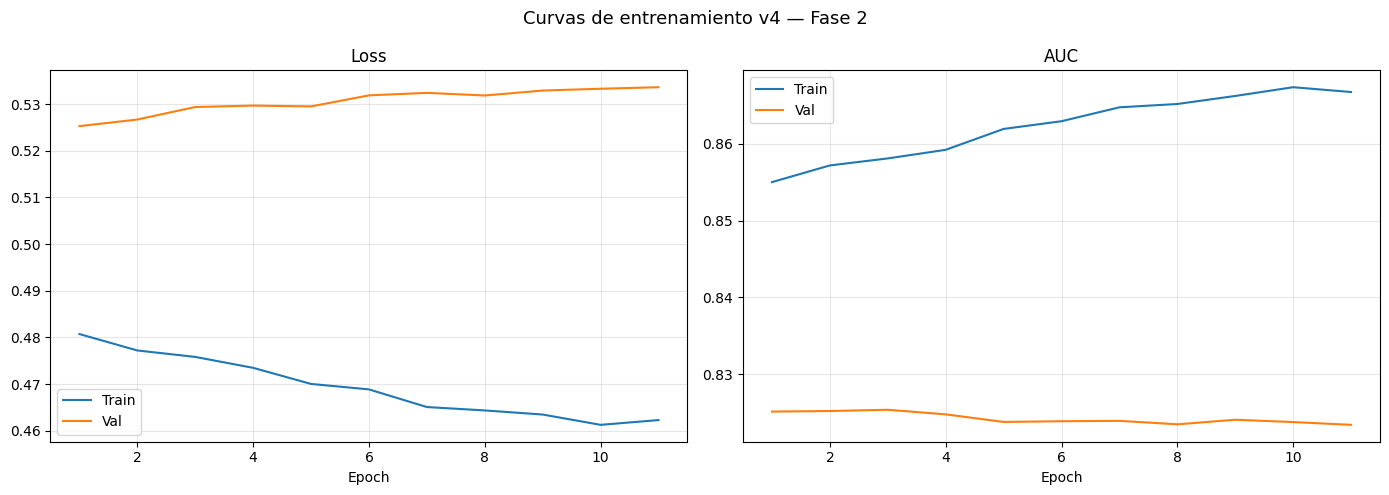

In [24]:
def graficar_una_fase(historia, titulo):
    epochs = range(1, len(historia.history["loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs, historia.history["loss"],     label="Train")
    ax1.plot(epochs, historia.history["val_loss"], label="Val")
    ax1.set_title("Loss"); ax1.set_xlabel("Epoch")
    ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(epochs, historia.history["auc"],     label="Train")
    ax2.plot(epochs, historia.history["val_auc"], label="Val")
    ax2.set_title("AUC"); ax2.set_xlabel("Epoch")
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.suptitle(f"Curvas de entrenamiento v4 — {titulo}", fontsize=13)
    plt.tight_layout()
    ruta = RUTA_CHECKPOINTS / NOMBRE_CURVAS
    plt.savefig(str(ruta), dpi=150, bbox_inches="tight")
    print(f"Guardada en: {ruta}")
    plt.show()

def graficar_ambas(h1, h2):
    loss_tr = h1.history["loss"]     + h2.history["loss"]
    loss_va = h1.history["val_loss"] + h2.history["val_loss"]
    auc_tr  = h1.history["auc"]      + h2.history["auc"]
    auc_va  = h1.history["val_auc"]  + h2.history["val_auc"]
    epochs  = range(1, len(loss_tr) + 1)
    sep     = len(h1.history["loss"])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for ax, tr, va, titulo in [(ax1, loss_tr, loss_va, "Loss"),
                                (ax2, auc_tr,  auc_va,  "AUC")]:
        ax.plot(epochs, tr, label="Train")
        ax.plot(epochs, va, label="Val")
        ax.axvline(sep, color="gray", linestyle="--",
                   alpha=0.6, label="Inicio fine-tuning")
        ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
    ax1.set_title("Loss"); ax2.set_title("AUC")
    plt.suptitle("Curvas de entrenamiento v4 — Fase 1 + Fase 2", fontsize=13)
    plt.tight_layout()
    ruta = RUTA_CHECKPOINTS / NOMBRE_CURVAS
    plt.savefig(str(ruta), dpi=150, bbox_inches="tight")
    print(f"Guardada en: {ruta}")
    plt.show()

try:
    graficar_ambas(historia_fase1, historia_fase2)
except NameError:
    try:
        graficar_una_fase(historia_fase2, "Fase 2")
    except NameError:
        graficar_una_fase(historia_fase1, "Fase 1")

## Celda 11 — Cargar mejor modelo y calibrar umbral sobre validacion

El umbral por defecto (0.5) no es necesariamente el optimo. Buscamos
el umbral que maximiza F1 sobre el conjunto de validacion — que el modelo
no uso para entrenar, solo para monitorear los callbacks.

Este `UMBRAL_OPTIMO` se aplica despues en la evaluacion de test.

Cargando mejor modelo de Fase 2: mejor_modelo_clasificacion_v4_f2.keras

Calibrando umbral sobre conjunto de validacion...
228/228 ━━━━━━━━━━━━━━━━━━━━ 41s 129ms/step

Umbral explorado            : 0.30 a 0.70
Umbral optimo (max F1 val)  : 0.38
F1 en val con umbral optimo : 0.782
F1 en val con umbral 0.50   : 0.768


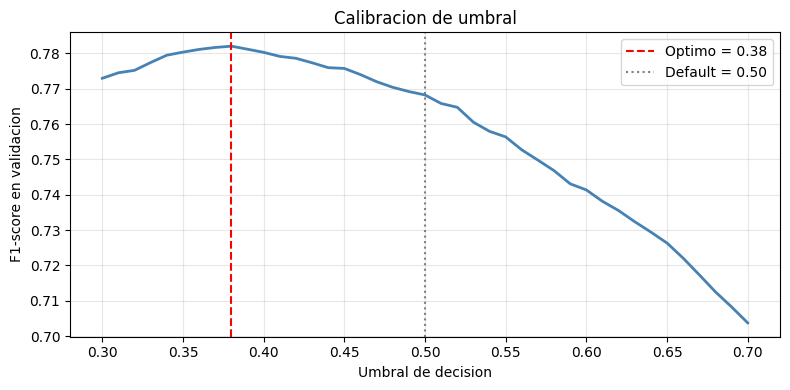


UMBRAL_OPTIMO = 0.38 se usara en la evaluacion de test.


In [28]:
# Cargar el mejor checkpoint disponible (preferir Fase 2)
if ruta_ckpt_f2.exists():
    ruta_mejor = ruta_ckpt_f2
    print(f"Cargando mejor modelo de Fase 2: {ruta_mejor.name}")
else:
    ruta_mejor = ruta_ckpt_f1
    print(f"Cargando mejor modelo de Fase 1: {ruta_mejor.name}")
    print("Nota: Fase 2 aun no completada.")

mejor_modelo = load_model(str(ruta_mejor))

# Predicciones sobre val
print("\nCalibrando umbral sobre conjunto de validacion...")
flujo_val.reset()
probs_val  = mejor_modelo.predict(flujo_val, verbose=1)
probs_val  = probs_val[:len(df_val)].flatten()
etiq_val   = df_val["label"].values

# Buscar umbral que maximiza F1
umbrales      = np.arange(0.30, 0.71, 0.01)
f1_por_umbral = [
    f1_score(etiq_val, (probs_val >= u).astype(int), zero_division=0)
    for u in umbrales
]

UMBRAL_OPTIMO = float(umbrales[np.argmax(f1_por_umbral)])
f1_optimo     = max(f1_por_umbral)
f1_default    = f1_score(etiq_val, (probs_val >= 0.5).astype(int))

print(f"\nUmbral explorado            : 0.30 a 0.70")
print(f"Umbral optimo (max F1 val)  : {UMBRAL_OPTIMO:.2f}")
print(f"F1 en val con umbral optimo : {f1_optimo:.3f}")
print(f"F1 en val con umbral 0.50   : {f1_default:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(umbrales, f1_por_umbral, color="steelblue", lw=2)
plt.axvline(UMBRAL_OPTIMO, color="red",  linestyle="--",
            label=f"Optimo = {UMBRAL_OPTIMO:.2f}")
plt.axvline(0.5,           color="gray", linestyle=":",
            label="Default = 0.50")
plt.xlabel("Umbral de decision")
plt.ylabel("F1-score en validacion")
plt.title("Calibracion de umbral")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nUMBRAL_OPTIMO = {UMBRAL_OPTIMO:.2f} se usara en la evaluacion de test.")

## Celda 12 — Evaluacion en test DatasetV2

Metricas sobre el test set del DatasetV2 usando el umbral calibrado.
Incluye matriz de confusion y classification report completo.

Generando predicciones en test DatasetV2...
230/230 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step

Matriz de confusion (test DatasetV2, umbral=0.38):
  Verdaderos negativos (TN): 4,299
  Falsos positivos    (FP): 2,046
  Falsos negativos    (FN): 1,563
  Verdaderos positivos (TP): 6,776

Metricas clinicas (test DatasetV2):
  Sensibilidad : 0.813
  Especificidad: 0.678
  Precision    : 0.768
  F1-Score     : 0.790

Matriz guardada en: /home/user/checkpoints/matriz_confusion_v4.png


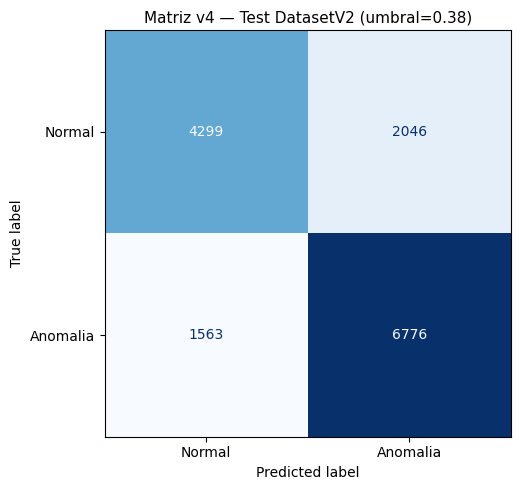


              precision    recall  f1-score   support

      Normal       0.73      0.68      0.70      6345
    Anomalia       0.77      0.81      0.79      8339

    accuracy                           0.75     14684
   macro avg       0.75      0.75      0.75     14684
weighted avg       0.75      0.75      0.75     14684



In [31]:
print("Generando predicciones en test DatasetV2...")
flujo_test.reset()
probabilidades      = mejor_modelo.predict(flujo_test, verbose=1)
probabilidades      = probabilidades[:len(df_test)]
etiquetas_reales    = df_test["label"].values
etiquetas_predichas = (probabilidades.flatten() >= UMBRAL_OPTIMO).astype(int)

cm = confusion_matrix(etiquetas_reales, etiquetas_predichas)
tn, fp, fn, tp = cm.ravel()

sensibilidad  = tp / (tp + fn)
especificidad = tn / (tn + fp)
precision_v   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
f1            = (2 * precision_v * sensibilidad / (precision_v + sensibilidad)
                 if (precision_v + sensibilidad) > 0 else 0.0)

print(f"\nMatriz de confusion (test DatasetV2, umbral={UMBRAL_OPTIMO:.2f}):")
print(f"  Verdaderos negativos (TN): {tn:,}")
print(f"  Falsos positivos    (FP): {fp:,}")
print(f"  Falsos negativos    (FN): {fn:,}")
print(f"  Verdaderos positivos (TP): {tp:,}")
print(f"\nMetricas clinicas (test DatasetV2):")
print(f"  Sensibilidad : {sensibilidad:.3f}")
print(f"  Especificidad: {especificidad:.3f}")
print(f"  Precision    : {precision_v:.3f}")
print(f"  F1-Score     : {f1:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Normal", "Anomalia"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(
    f"Matriz v4 — Test DatasetV2 (umbral={UMBRAL_OPTIMO:.2f})", fontsize=11)
plt.tight_layout()
ruta_matriz = RUTA_CHECKPOINTS / NOMBRE_MATRIZ
plt.savefig(str(ruta_matriz), dpi=150, bbox_inches="tight")
print(f"\nMatriz guardada en: {ruta_matriz}")
plt.show()

print()
print(classification_report(
    etiquetas_reales, etiquetas_predichas,
    target_names=["Normal", "Anomalia"]
))

## Celda 13 — Curva AUC-ROC

La curva ROC muestra el tradeoff sensibilidad/especificidad a todos los
umbrales posibles. El punto marcado indica el umbral calibrado optimo.
AUC = 1.0 es perfecto; AUC = 0.5 equivale a clasificar al azar.

Curva ROC guardada en: /home/user/checkpoints/curva_roc_v4.png
  AUC v4 DatasetV2: 0.833


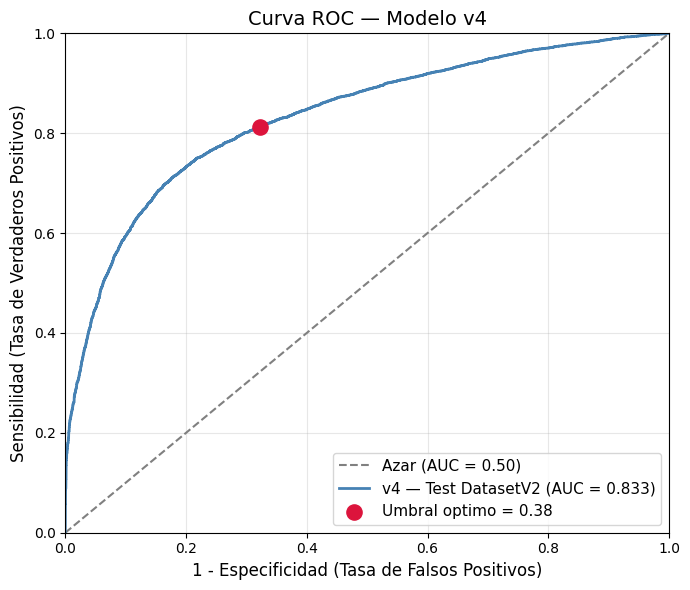

In [33]:
fpr, tpr, _ = roc_curve(etiquetas_reales, probabilidades.flatten())
auc_score   = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot([0, 1], [0, 1], "--", color="gray", label="Azar (AUC = 0.50)")
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"v4 — Test DatasetV2 (AUC = {auc_score:.3f})")

# Punto de operacion con umbral calibrado
ax.scatter([1 - especificidad], [sensibilidad],
           color="crimson", s=120, zorder=5,
           label=f"Umbral optimo = {UMBRAL_OPTIMO:.2f}")

ax.set_xlabel("1 - Especificidad (Tasa de Falsos Positivos)", fontsize=12)
ax.set_ylabel("Sensibilidad (Tasa de Verdaderos Positivos)", fontsize=12)
ax.set_title("Curva ROC — Modelo v4", fontsize=14)
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
ax.grid(alpha=0.3)
plt.tight_layout()

ruta_roc = RUTA_CHECKPOINTS / "curva_roc_v4.png"
plt.savefig(str(ruta_roc), dpi=150, bbox_inches="tight")
print(f"Curva ROC guardada en: {ruta_roc}")
print(f"  AUC v4 DatasetV2: {auc_score:.3f}")
plt.show()

## Celda 14 — Resumen comparativo de resultados

**Tabla 1** — Evolucion en test propio.
v1 y v2 evaluados en NIH. v3 y v4 en DatasetV2 (NIH + CheXpert).
Rellenar columna v3 cuando ese modelo termine.

**Tabla 2** — Evolucion en Chest X-Ray omitida: las radiografias de ese
dataset son en vista AP, incompatible con el entrenamiento en vista PA.

In [34]:
# Resultados historicos — del notebook v2 y v3 ya ejecutados
V1_SENS  = 0.544; V1_ESP = 0.790; V1_PREC = 0.649; V1_F1 = 0.592
V2_SENS  = 0.582; V2_ESP = 0.756; V2_PREC = 0.636; V2_F1 = 0.608
V3_SENS  = 0.759; V3_ESP = 0.563; V3_PREC = 0.561; V3_F1 = 0.645

def fmt(val):
    return f"{val:.3f}" if val is not None else "  —  "

def cambio(nuevo, viejo):
    if nuevo is None or viejo is None: return "  —  "
    diff = nuevo - viejo
    return f"{'▲' if diff >= 0 else '▼'} {abs(diff):.3f}"

print("=" * 72)
print("TABLA 1 — Evolucion del modelo en test propio")
print("  v1 y v2: evaluados en NIH.")
print("  v3 y v4: evaluados en DatasetV2 (NIH + CheXpert).")
print("=" * 72)
print(f"  {'Metrica':<16} {'v1 (NIH)':>10} {'v2 (NIH)':>10} "
      f"{'v3 (DV2)':>10} {'v4 (DV2)':>10} {'v3→v4':>10}")
print("  " + "-" * 68)

for metrica, v1, v2, v3, v4 in [
    ("Sensibilidad", V1_SENS, V2_SENS, V3_SENS, sensibilidad),
    ("Especificidad", V1_ESP,  V2_ESP,  V3_ESP,  especificidad),
    ("Precision",    V1_PREC, V2_PREC, V3_PREC, precision_v),
    ("F1-Score",     V1_F1,   V2_F1,   V3_F1,   f1),
]:
    print(f"  {metrica:<16} {fmt(v1):>10} {fmt(v2):>10} "
          f"{fmt(v3):>10} {fmt(v4):>10} {cambio(v4, v3):>10}")

print()
print(f"  AUC-ROC v4 (test DatasetV2): {auc_score:.3f}")
print(f"  Umbral calibrado            : {UMBRAL_OPTIMO:.2f}")
print()
print("  ▲ = mejora respecto a v3   ▼ = retroceso respecto a v3")


TABLA 1 — Evolucion del modelo en test propio
  v1 y v2: evaluados en NIH.
  v3 y v4: evaluados en DatasetV2 (NIH + CheXpert).
  Metrica            v1 (NIH)   v2 (NIH)   v3 (DV2)   v4 (DV2)      v3→v4
  --------------------------------------------------------------------
  Sensibilidad          0.544      0.582      0.759      0.813    ▲ 0.054
  Especificidad         0.790      0.756      0.563      0.678    ▲ 0.115
  Precision             0.649      0.636      0.561      0.768    ▲ 0.207
  F1-Score              0.592      0.608      0.645      0.790    ▲ 0.145

  AUC-ROC v4 (test DatasetV2): 0.833
  Umbral calibrado            : 0.38

  ▲ = mejora respecto a v3   ▼ = retroceso respecto a v3


## Celda 15 — Guardar backbone v4

Extrae y guarda el backbone para que NB03 y NB04 lo reutilicen.
Salida: `(None, 7, 7, 1024)` — los otros notebooks deben agregar
`GlobalAveragePooling2D` antes de su propia cabeza.

Al terminar, subir al bucket:
```bash
gsutil -m cp -r /home/user/checkpoints/ gs://vena-dataset/checkpoints_v4/
```

In [35]:
ruta_backbone = RUTA_CHECKPOINTS / NOMBRE_BACKBONE

if ruta_backbone.exists():
    print(f"{NOMBRE_BACKBONE} ya existe. No se sobreescribe.")
else:
    nombres  = [capa.name for capa in mejor_modelo.layers]
    idx_pool = next(i for i, n in enumerate(nombres) if "global_average" in n)
    backbone = Model(
        inputs  = mejor_modelo.input,
        outputs = mejor_modelo.layers[idx_pool - 1].output,
        name    = "backbone_densenet121_v4"
    )
    backbone.save(str(ruta_backbone))
    print(f"Backbone guardado en: {ruta_backbone}")
    print(f"  Entrada : {backbone.input_shape}")
    print(f"  Salida  : {backbone.output_shape}")

print()
print("Archivos generados (v4):")
for archivo in sorted(RUTA_CHECKPOINTS.iterdir()):
    if "v4" in archivo.name:
        print(f"  {archivo.name} ({archivo.stat().st_size / 1024**2:.1f} MB)")

print()
print("Subir al bucket:")
print("  gsutil -m cp -r /home/user/checkpoints/ gs://vena-dataset/checkpoints_v4/")

Backbone guardado en: /home/user/checkpoints/backbone_densenet121_v4.keras
  Entrada : (None, 224, 224, 3)
  Salida  : (None, 7, 7, 1024)

Archivos generados (v4):
  backbone_densenet121_v4.keras (28.3 MB)
  curva_roc_v4.png (0.1 MB)
  curvas_entrenamiento_v4.png (0.1 MB)
  matriz_confusion_v4.png (0.0 MB)
  mejor_modelo_clasificacion_v4_f1.keras (33.3 MB)
  mejor_modelo_clasificacion_v4_f2.keras (62.0 MB)

Subir al bucket:
  gsutil -m cp -r /home/user/checkpoints/ gs://vena-dataset/checkpoints_v4/
